In [1]:
from read import image_to_graph
from stoer_wagner import stoer_wagner
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def load(filepath, size=256):
    img = Image.open(filepath).convert("L").resize((size, size))
    img.save("temp.png")
    return image_to_graph("temp.png")

In [3]:
G = load("dat/star.png", size=32)
print(len(G.nodes), len(G.edges))

1024 1984


In [4]:
side_a, side_b = stoer_wagner(G, min_partition_fraction=0.05, verbose= True)
print(f"Partition sizes: {len(side_a)} / {len(side_b)}")

starting: 1024 nodes, 1984 edges
total_vol=330365.87, min_vol=16518.29

phase    1/1023  nodes=1024  cut=   62.01  vol_t=   62.01  score=  --    skip
phase    2/1023  nodes=1023  cut=   62.01  vol_t=   62.01  score=  --    skip
phase    3/1023  nodes=1022  cut=    8.10  vol_t=    8.10  score=  --    skip
phase    4/1023  nodes=1021  cut=    8.31  vol_t=    8.31  score=  --    skip
phase    5/1023  nodes=1020  cut=    8.34  vol_t=    8.34  score=  --    skip
phase    6/1023  nodes=1019  cut=   18.37  vol_t=   18.37  score=  --    skip
phase    7/1023  nodes=1018  cut=   18.37  vol_t=   18.37  score=  --    skip
phase    8/1023  nodes=1017  cut=   11.21  vol_t=   11.21  score=  --    skip
phase    9/1023  nodes=1016  cut=    8.89  vol_t=    8.89  score=  --    skip
phase   10/1023  nodes=1015  cut=    8.98  vol_t=    8.98  score=  --    skip
phase   11/1023  nodes=1014  cut=    9.81  vol_t=    9.81  score=  --    skip
phase   12/1023  nodes=1013  cut=    9.81  vol_t=    9.81  score=  -- 

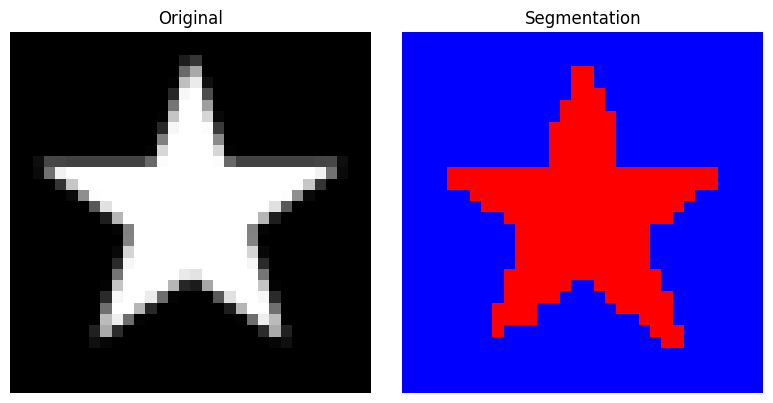

In [5]:
size = int(len(G.nodes) ** 0.5)
mask = np.zeros((size, size))
for (r, c) in side_b:
    mask[r, c] = 1
 
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(Image.open("temp.png"), cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(mask, cmap="bwr")
axes[1].set_title("Segmentation")
axes[1].axis("off")
plt.tight_layout()
plt.savefig("output.png")
plt.show()

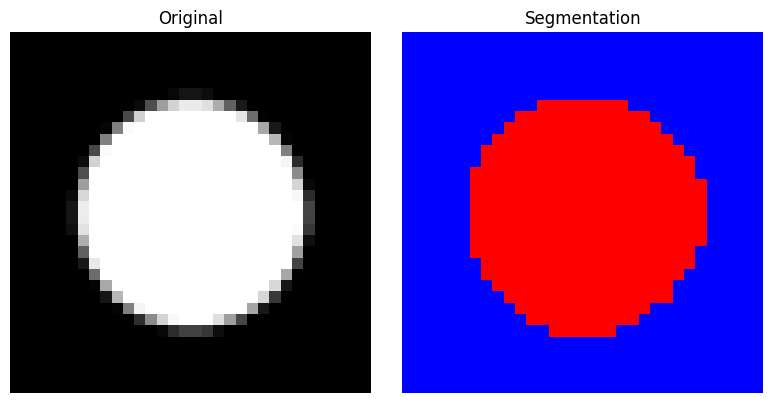

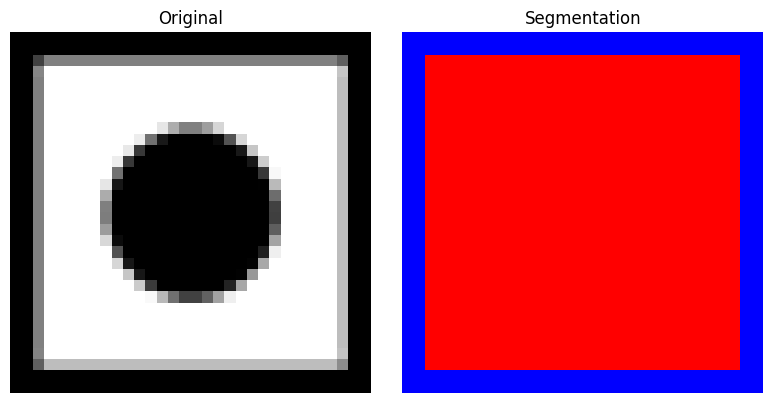

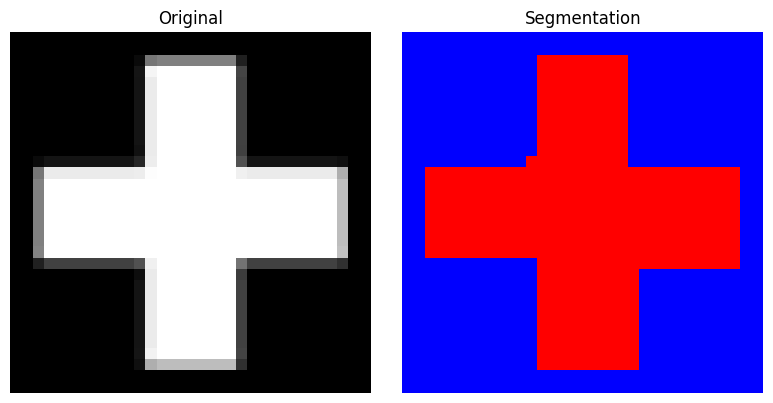

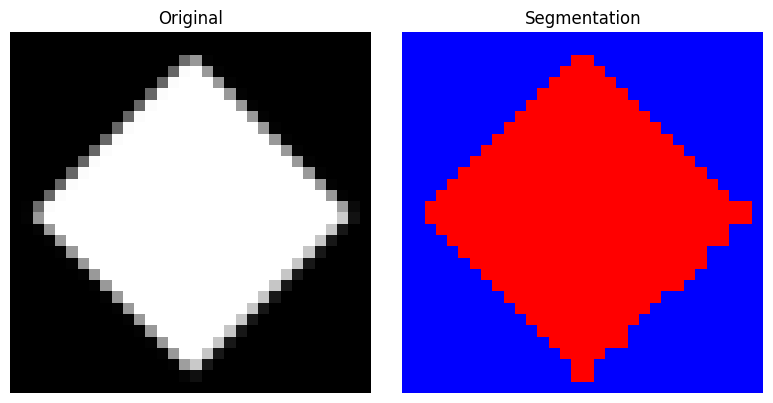

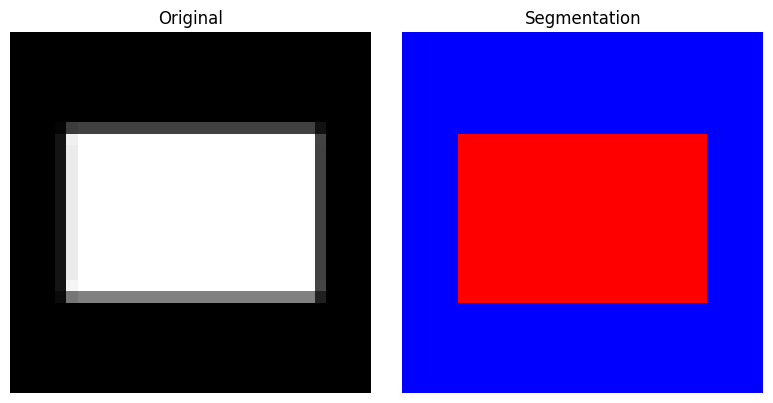

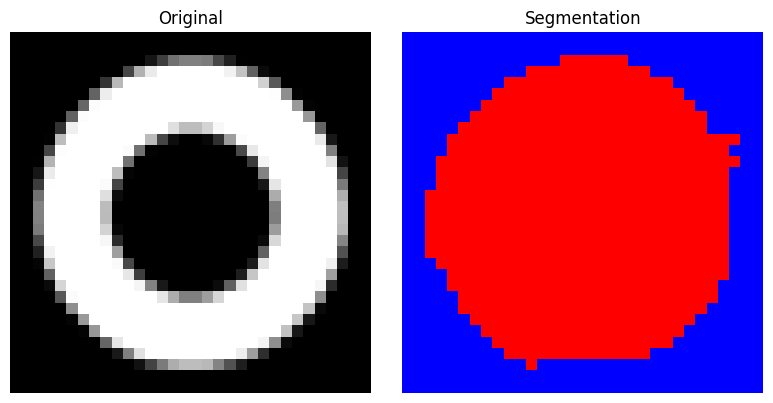

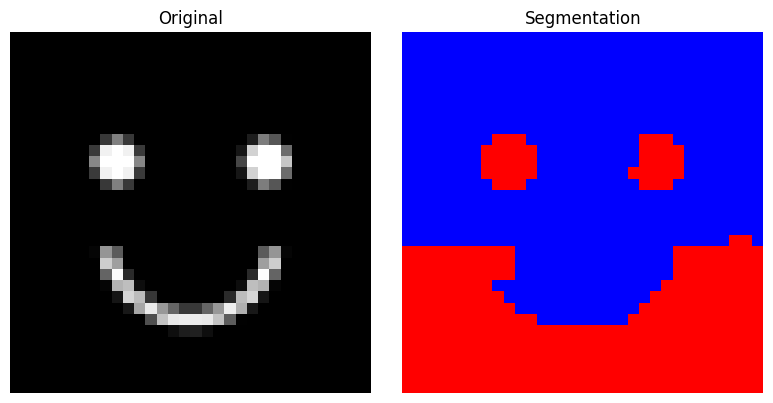

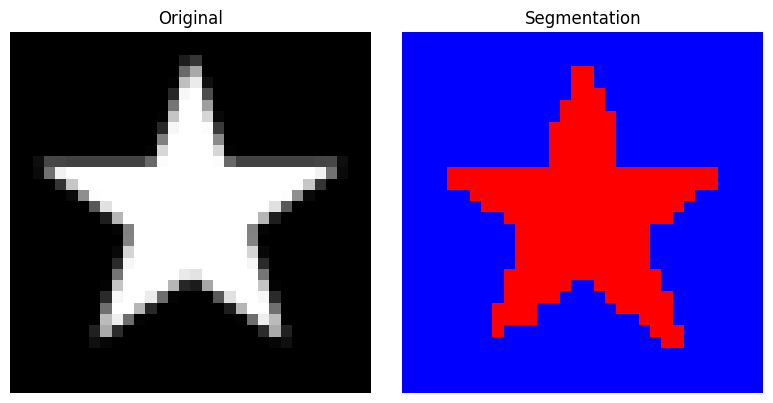

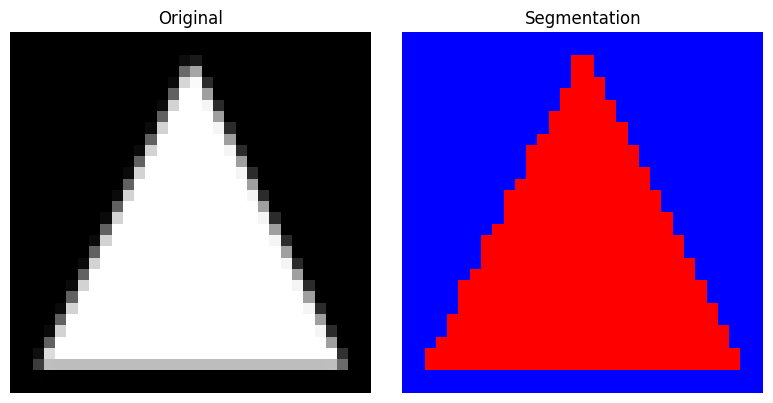

In [6]:
import os
for filename in os.listdir("dat"):
    if filename.endswith(".png"):
        shape = filename[:-4]
        G = load(f"dat\\{filename}", size=32)
        side_a, side_b = stoer_wagner(G, min_partition_fraction=0.05)
        size = int(len(G.nodes) ** 0.5)

        mask = np.zeros((size, size))
        for (r, c) in side_b:
            mask[r, c] = 1
        
        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        axes[0].imshow(Image.open("temp.png"), cmap="gray")
        axes[0].set_title("Original")
        axes[0].axis("off")
        axes[1].imshow(mask, cmap="bwr")
        axes[1].set_title("Segmentation")
        axes[1].axis("off")
        plt.tight_layout()
        plt.savefig(f"output_{shape}.png")
        plt.show()
